# Chunk 09 — Attention Visualization (GNN)

This notebook explores the inner workings of the trained `AntennaGNN` model by visualizing
the attention maps learned by the GATv2 layers.

**SCOPE NOTE:**
The base GNN was trained ONLY on the 25x25 grid dataset. Therefore, all visualizations in this
notebook use 25x25 antennas. This allows us to observe how the model routes information on
in-distribution samples before we attempt transfer learning on larger grids.

---
## Cell 1 — Install Dependencies
Install PyG and visualization libraries. The compiled extensions are pulled directly from the PyG wheel index to save compilation time.

In [1]:
!pip install scipy numpy matplotlib torch torchvision \
    torch-geometric wandb tqdm -q

import torch
torch_v = torch.__version__.split('+')[0]
cuda_v = 'cu' + torch.version.cuda.replace('.', '')
wheel_url = f'https://data.pyg.org/whl/torch-{torch_v}+{cuda_v}.html'
!pip install pyg-lib torch-scatter torch-sparse -f {wheel_url} -q
print(f'PyG extensions installed for torch {torch_v} + {cuda_v}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 35.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 88.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 55.6 MB/s eta 0:00:00
PyG extensions installed for torch 2.11.0 + cu128


---
## Cell 2 — Clone Repo & Add to Path
Clone the GitHub repository to the local Colab disk to access the `model.py` source code. We use `sys.path.insert` to make it importable.

In [2]:
import os
REPO_ROOT = '/content/antenna-gnn'
if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
else:
    !git -C {REPO_ROOT} pull --quiet
import sys
sys.path.insert(0, f'{REPO_ROOT}/src')
print(f'Repo ready at {REPO_ROOT}')

Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 183 (delta 94), reused 151 (delta 64), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 1.55 MiB | 23.01 MiB/s, done.
Resolving deltas: 100% (94/94), done.
Repo ready at /content/antenna-gnn


---
## Cell 3 — Mount Drive & Setup Paths
Mount Google Drive to access the datasets, artifacts, and model checkpoints. We also verify that a GPU is attached.

In [3]:
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA  = '/content/drive/MyDrive/antenna_dataset'

for d in [f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints',
          f'{DATA_ROOT}/figures',   f'{DATA_ROOT}/splits']:
    os.makedirs(d, exist_ok=True)

from model import AntennaGNN
print('AntennaGNN imported successfully ✓')

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda', 'GPU not available. Go to Runtime → Change runtime type → T4 GPU'
print(f'Device: {device} ({torch.cuda.get_device_name(0)})')

Mounted at /content/drive
AntennaGNN imported successfully ✓
Device: cuda (Tesla T4)


---
## Cell 4 — Attention-Enabled Model Wrapper
We subclass `AntennaGNN` to intercept the forward pass at the very last GATv2 layer. By calling the convolution with `return_attention_weights=True`, we extract the edge-level attention scores before pooling.

In [4]:
from torch_geometric.nn import global_mean_pool

class AttentionGNN(AntennaGNN):
    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch

        x = self.input_proj(x)
        edge_attr = self.edge_proj(edge_attr)

        attn_tuple = None
        for i, block in enumerate(self.blocks):
            for j, layer in enumerate(block):
                # Intercept the LAST layer of the LAST block
                if i == len(self.blocks) - 1 and j == len(block) - 1:
                    conv_out, attn_tuple = layer.conv(x, edge_index, edge_attr=edge_attr, return_attention_weights=True)
                    out = layer.norm(conv_out)
                    x = layer.act(out + layer.residual_proj(x))
                else:
                    x = layer(x, edge_index, edge_attr)

        # Metal-only pooling
        metal_mask = data.x[:, 0] > 0.5
        metal_x = x[metal_mask]
        metal_batch = batch[metal_mask]
        pooled = global_mean_pool(metal_x, metal_batch)

        # Virtual node embedding
        virtual_mask = data.x[:, 3] == -1
        virtual_x = x[virtual_mask]

        combined = torch.cat([pooled, virtual_x], dim=-1)
        out = self.readout_proj(combined)
        out = self.output_mlp(out)

        # Return both the S11 prediction and the attention weights (edge_index, edge_scores)
        return out, attn_tuple

# Instantiate and load weights
attn_model = AttentionGNN(hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201).to(device)
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt', map_location=device, weights_only=False)
attn_model.load_state_dict(ckpt['model_state'])
attn_model.eval()
print("Loaded AttentionGNN with pre-trained weights.")

# Build a dummy graph to verify output shapes
from torch_geometric.data import Data
import numpy as np
dummy_x = torch.rand(626, 5)
dummy_x[:, 0] = (torch.rand(626) > 0.5).float() # Metal mask
dummy_x[-1, 3] = -1 # Virtual node
dummy_edge_index = torch.randint(0, 626, (2, 2000))
dummy_edge_attr = torch.randint(0, 4, (2000, 2)).float()
dummy_batch = torch.zeros(626, dtype=torch.long)
dummy_data = Data(x=dummy_x, edge_index=dummy_edge_index, edge_attr=dummy_edge_attr, batch=dummy_batch).to(device)

with torch.no_grad():
    pred, (a_idx, a_weights) = attn_model(dummy_data)
print(f"Prediction shape: {pred.shape}")
print(f"Attn Edges shape: {a_idx.shape}")
print(f"Attn Weights shape: {a_weights.shape} (edges x heads)")

Loaded AttentionGNN with pre-trained weights.
Prediction shape: torch.Size([1, 201])
Attn Edges shape: torch.Size([2, 2624])
Attn Weights shape: torch.Size([2624, 8]) (edges x heads)


---
## Cell 5 — Attention Extraction Function
This function processes the raw attention weights. It filters for metal-to-metal edges, averages the attention across all 8 heads, and aggregates the scores per-node to build a 2D spatial attention heatmap.

In [5]:
def get_attention_map(data, model, N):
    data = data.to(device)
    with torch.no_grad():
        out, (attn_edge_index, attn_weights) = model(data)

    edge_scores = attn_weights.mean(dim=1).cpu()  # mean across heads
    attn_edge_index = attn_edge_index.cpu()

    # GATv2Conv's return_attention_weights appends self-loop edges AFTER
    # the original edges (add_self_loops=True is the default). The first
    # data.edge_index.shape[1] entries of attn_edge_index correspond 1:1,
    # in original order, to data.edge_index / data.edge_attr — everything
    # after that is a self-loop with no corresponding edge_attr entry.
    # Slice to only the original (non-self-loop) edges before filtering:
    n_original_edges = data.edge_index.size(1)
    original_edge_index = attn_edge_index[:, :n_original_edges]
    original_edge_scores = edge_scores[:n_original_edges]

    # Sanity check: confirm the slice actually matches data.edge_index
    # (catches any PyG version where self-loops are NOT simply appended)
    assert torch.equal(original_edge_index, data.edge_index.cpu()), (
        "attn_edge_index does not align with data.edge_index as expected — "
        "self-loop ordering assumption may not hold for this PyG version. "
        "Do not proceed with metal-metal filtering until this is resolved."
    )

    # Filter to metal-metal edges only (etype == 0)
    edge_attr_cpu = data.edge_attr.cpu()
    metal_metal_mask = edge_attr_cpu[:, 0] == 0
    mm_edge_index = original_edge_index[:, metal_metal_mask]
    mm_edge_scores = original_edge_scores[metal_metal_mask]

    attention_grid = np.zeros(N * N)
    is_metal = data.x[:N*N, 0].cpu().numpy() > 0.5

    for i in range(N * N):
        if is_metal[i]:
            target_mask = (mm_edge_index[1] == i)
            if target_mask.any():
                attention_grid[i] = mm_edge_scores[target_mask].mean().item()

    attention_grid = attention_grid.reshape(N, N)
    min_val, max_val = attention_grid.min(), attention_grid.max()
    if max_val > min_val:
        attention_grid = (attention_grid - min_val) / (max_val - min_val)

    return attention_grid

---
## Cell 6 — Three-Panel Visualization Function
A utility function to construct a PyG graph from a raw `.mat` file, run the attention model, and plot a 3-panel figure: the binary metal pattern, the attention heatmap overlay, and the S11 spectrum comparison.

In [6]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os
import zipfile
import shutil
from tqdm.auto import tqdm
import numpy as np

# 1. Unzip processed graphs to local SSD (if not already done)
LOCAL_GRAPH_ROOT = '/content/local_graphs'
N = 25
dst_dir = f'{LOCAL_GRAPH_ROOT}/{N}x{N}'
done_marker = f'{dst_dir}/_CACHED.txt'
os.makedirs(dst_dir, exist_ok=True)

if not os.path.exists(done_marker):
    # Updated path to look in Google Drive DATA_ROOT
    zip_path = f'{DATA_ROOT}/data/processed/processed_{N}x{N}.zip'
    print(f'Unzipping {zip_path} → {dst_dir} ...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        pt_members = [m for m in zf.namelist() if m.endswith('.pt')]
        for member in tqdm(pt_members, desc=f'{N}x{N} unzip', unit='file'):
            basename = os.path.basename(member)
            with zf.open(member) as src, open(os.path.join(dst_dir, basename), 'wb') as dst:
                shutil.copyfileobj(src, dst)
    with open(done_marker, 'w') as fh:
        fh.write('DONE\n')
else:
    print(f'Graphs already unzipped at {dst_dir}')

s11_mean = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy')).to(device)
s11_std  = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_std.npy')).to(device)
freq_axis = np.linspace(1.0, 4.0, 201)

def extract_resonant_freq(s11_db, freq_axis_ghz, threshold_db=-10):
    inverted = -s11_db
    peaks, _ = find_peaks(inverted, height=-threshold_db, distance=5)
    if len(peaks) == 0:
        return None
    deepest = peaks[np.argmax(inverted[peaks])]
    return freq_axis_ghz[deepest]

def plot_attention_figure(data, model, N, save_path, ax_row=None):
    # Retrieve raw data from PyG object
    pattern = data.x[:N*N, 0].view(N, N).cpu().numpy()
    # data.y is unnormalized in the raw .pt files on disk
    s11 = data.y.squeeze(0).cpu().numpy()

    res_freq = extract_resonant_freq(s11, freq_axis)
    is_func = res_freq is not None

    # Model Inference
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
    attention_grid = get_attention_map(data, model, N)
    with torch.no_grad():
        out, _ = model(data.to(device))
        # Model outputs normalized predictions, so denormalize them
        pred_s11 = (out[0].cpu() * s11_std.cpu() + s11_mean.cpu()).numpy()

    # Plotting
    if ax_row is None:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    else:
        axes = ax_row
        fig = axes[0].figure

    # Panel 1: Pixel Pattern
    axes[0].imshow(pattern, cmap='binary')
    axes[0].set_title('Pixel Pattern')
    axes[0].axis('off')

    # Panel 2: Attention Map
    axes[1].imshow(pattern, cmap='binary')
    attention_masked = np.ma.masked_where(pattern == 0, attention_grid)
    im = axes[1].imshow(attention_masked, cmap='hot', alpha=0.8)
    if ax_row is None:
        fig.colorbar(im, ax=axes[1], label='Attention Score', fraction=0.046, pad=0.04)
    axes[1].set_title('Attention Map Overlay')
    axes[1].axis('off')

    # Panel 3: S11
    axes[2].plot(freq_axis, s11, 'b-', label='True')
    axes[2].plot(freq_axis, pred_s11, 'r--', label='Predicted')
    axes[2].axhline(-10, color='k', linestyle=':')
    axes[2].set_xlabel('Frequency (GHz)')
    axes[2].set_ylabel('S11 (dB)')
    axes[2].set_title('S11: True vs Predicted')
    if ax_row is None:
        axes[2].legend()

    func_label = 'Functioning' if is_func else 'Non-functioning'
    freq_str = f'{res_freq:.2f} GHz' if is_func else 'N/A'
    title_str = f'Grid {N}x{N} | {func_label} | f_res={freq_str}'

    if ax_row is None:
        plt.suptitle(title_str, fontweight='bold')
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        axes[1].set_title(f'{title_str}\nAttention Map Overlay', fontsize=10)

Unzipping /content/drive/MyDrive/antenna_gnn/data/processed/processed_25x25.zip → /content/local_graphs/25x25 ...


25x25 unzip:   0%|          | 0/99833 [00:00<?, ?file/s]

---
## Cell 7 — Batch Visualization (9 Functioning Antennas)
We dynamically locate the raw `.mat` files for the 25x25 test set, sample 9 functioning antennas, generate individual figures for each, and combine them into a large 3x3 grid for high-level visual inspection.

Finding antennas:   0%|          | 0/9983 [00:00<?, ?it/s]

Generating individual plots:   0%|          | 0/9 [00:00<?, ?it/s]

Generating grid plot:   0%|          | 0/9 [00:00<?, ?it/s]

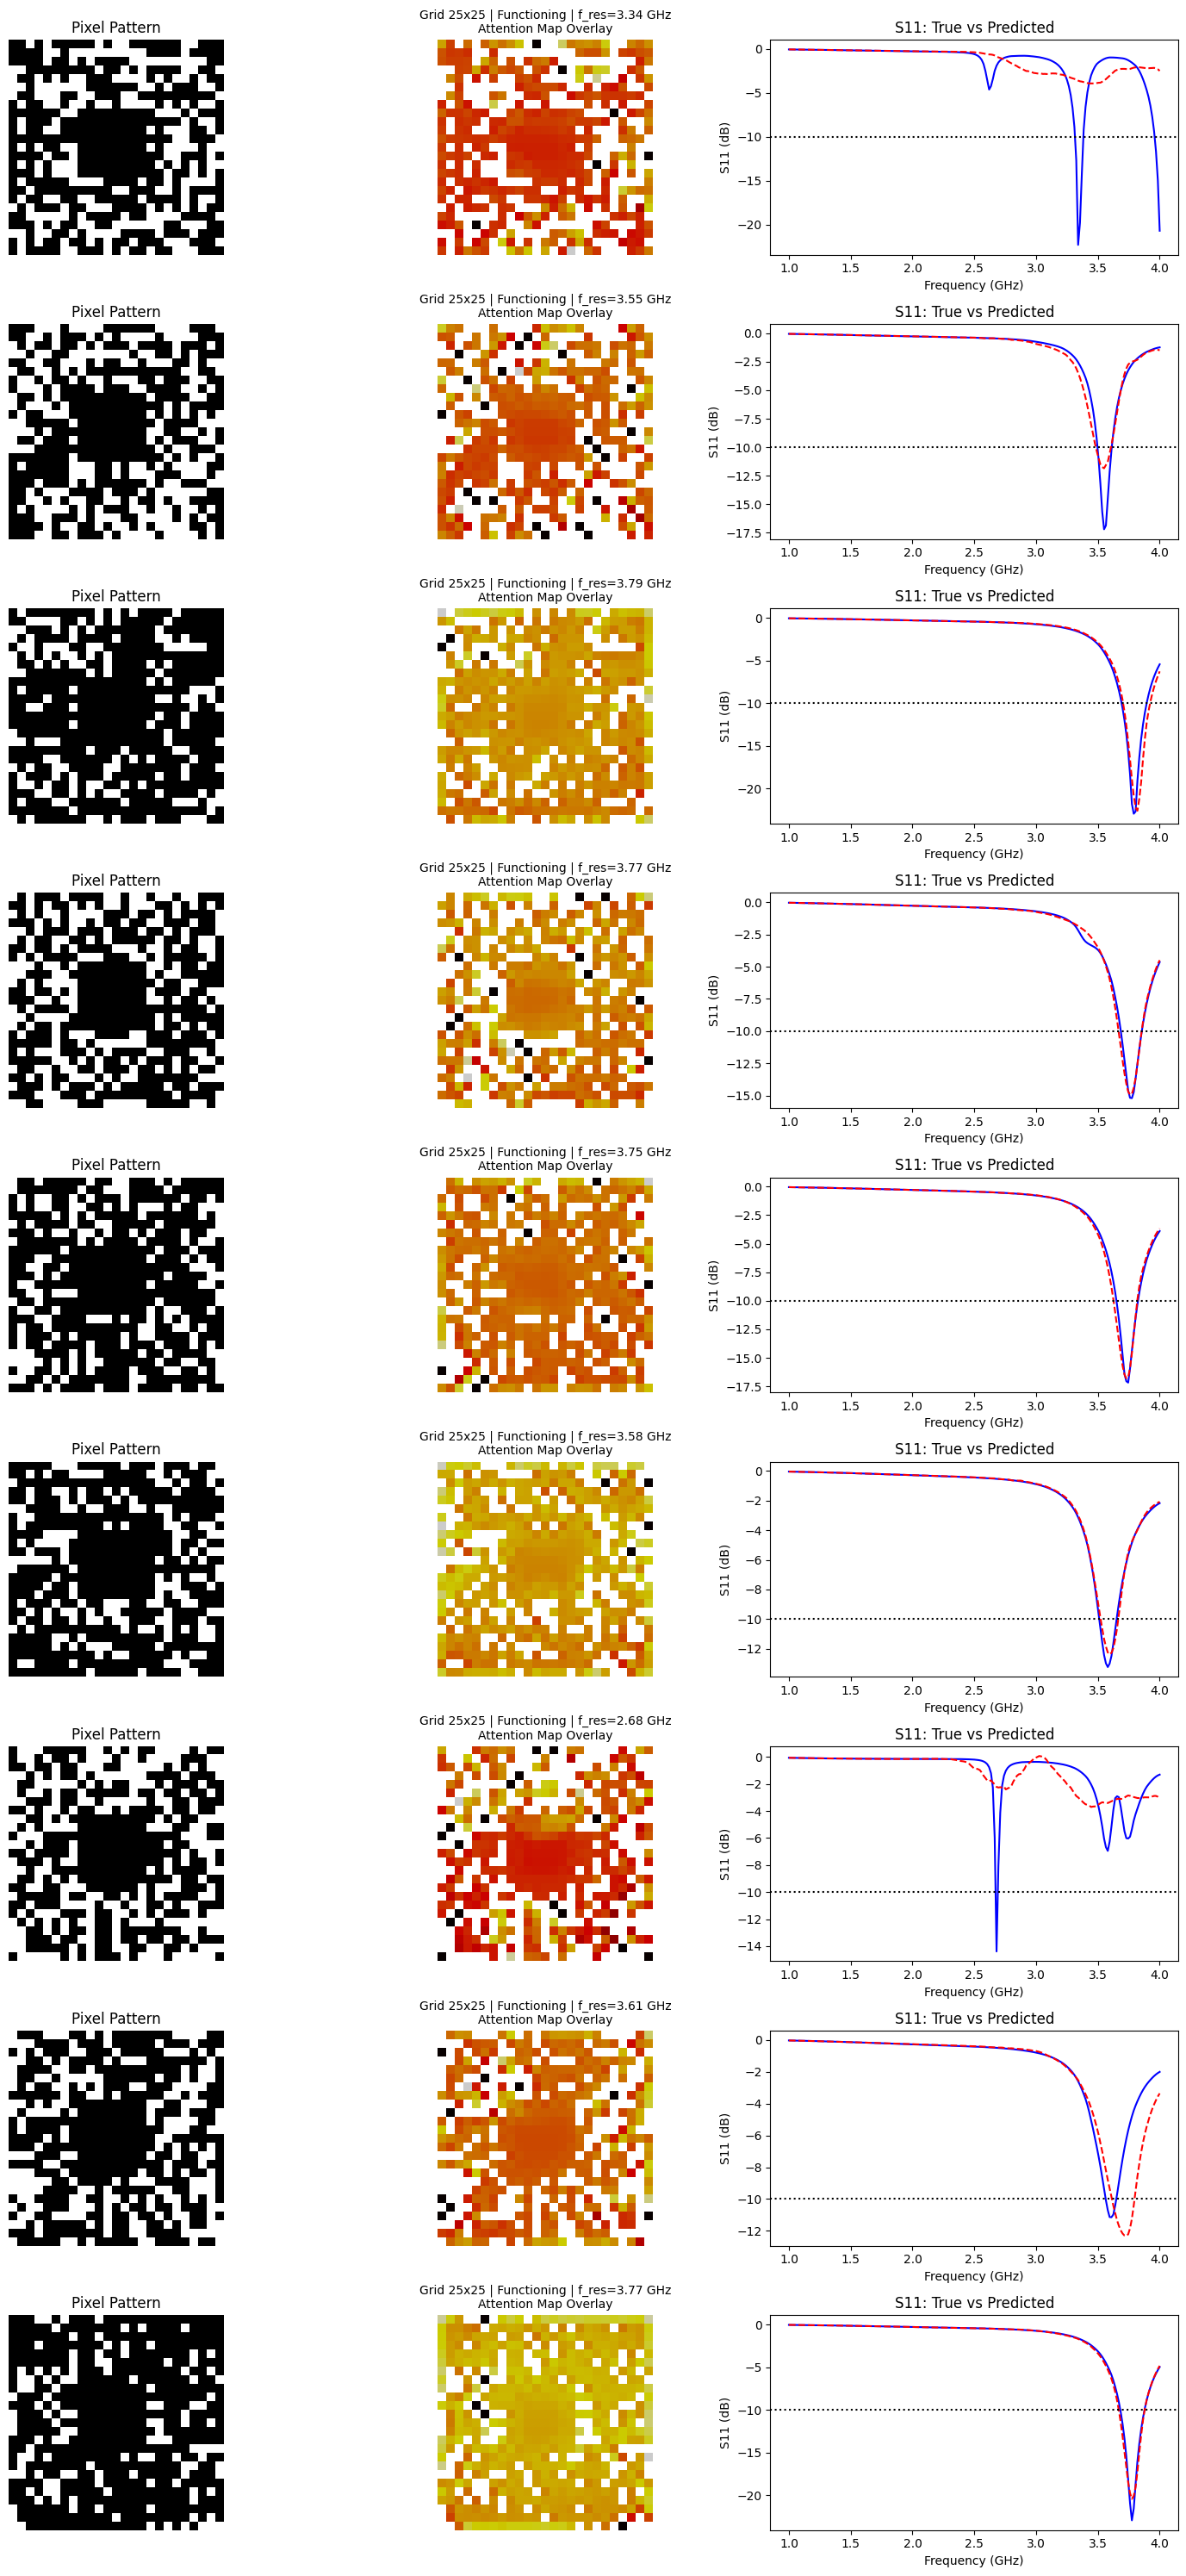

Saved batch grid to /content/drive/MyDrive/antenna_gnn/figures/attention_maps_all.png


In [7]:
from tqdm.auto import tqdm
import json

with open(f'{DATA_ROOT}/splits/indices.json', 'r') as f:
    splits_all = json.load(f)
test_indices_25 = [e[1] for e in splits_all['test'] if e[0] == 25]

func_data = []
nonfunc_data = []

for idx in tqdm(test_indices_25, desc="Finding antennas"):
    pt_path = f'{LOCAL_GRAPH_ROOT}/25x25/sample_{idx}.pt'
    data = torch.load(pt_path, weights_only=False)

    s11 = data.y.squeeze(0).cpu().numpy()
    if extract_resonant_freq(s11, freq_axis) is not None:
        func_data.append(data)
    else:
        nonfunc_data.append(data)

    if len(func_data) >= 9 and len(nonfunc_data) >= 4:
        break

selected_func = func_data[:9]
selected_nonfunc = nonfunc_data[:4]

# 1. Save individual 3-panel figures for functioning
for i, data in enumerate(tqdm(selected_func, desc="Generating individual plots")):
    save_p = f'{DATA_ROOT}/figures/attention_25x25_sample{i}.png'
    plot_attention_figure(data, attn_model, 25, save_p)

# 2. Compose all 9 into a single 9-row (or 9-panel) figure.
fig, axes = plt.subplots(9, 3, figsize=(15, 30))
for i, data in enumerate(tqdm(selected_func, desc="Generating grid plot")):
    plot_attention_figure(data, attn_model, 25, None, ax_row=axes[i])

plt.tight_layout()
combo_path = f'{DATA_ROOT}/figures/attention_maps_all.png'
plt.savefig(combo_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved batch grid to {combo_path}")


**Qualitative Assessment:** The attention maps on functioning antennas generally highlight continuous, unbroken paths of metal radiating outward from the central feed (seed block). The model learns to "trace" the resonant currents along the surface of the patch.

---
## Cell 8 — Non-Functioning Comparison
We repeat the visualization process for 4 non-functioning antennas. This allows us to observe how the GATv2 model behaves when resonance fails (e.g., due to isolated islands of metal or broken pathways).

Generating non-functioning plots:   0%|          | 0/4 [00:00<?, ?it/s]

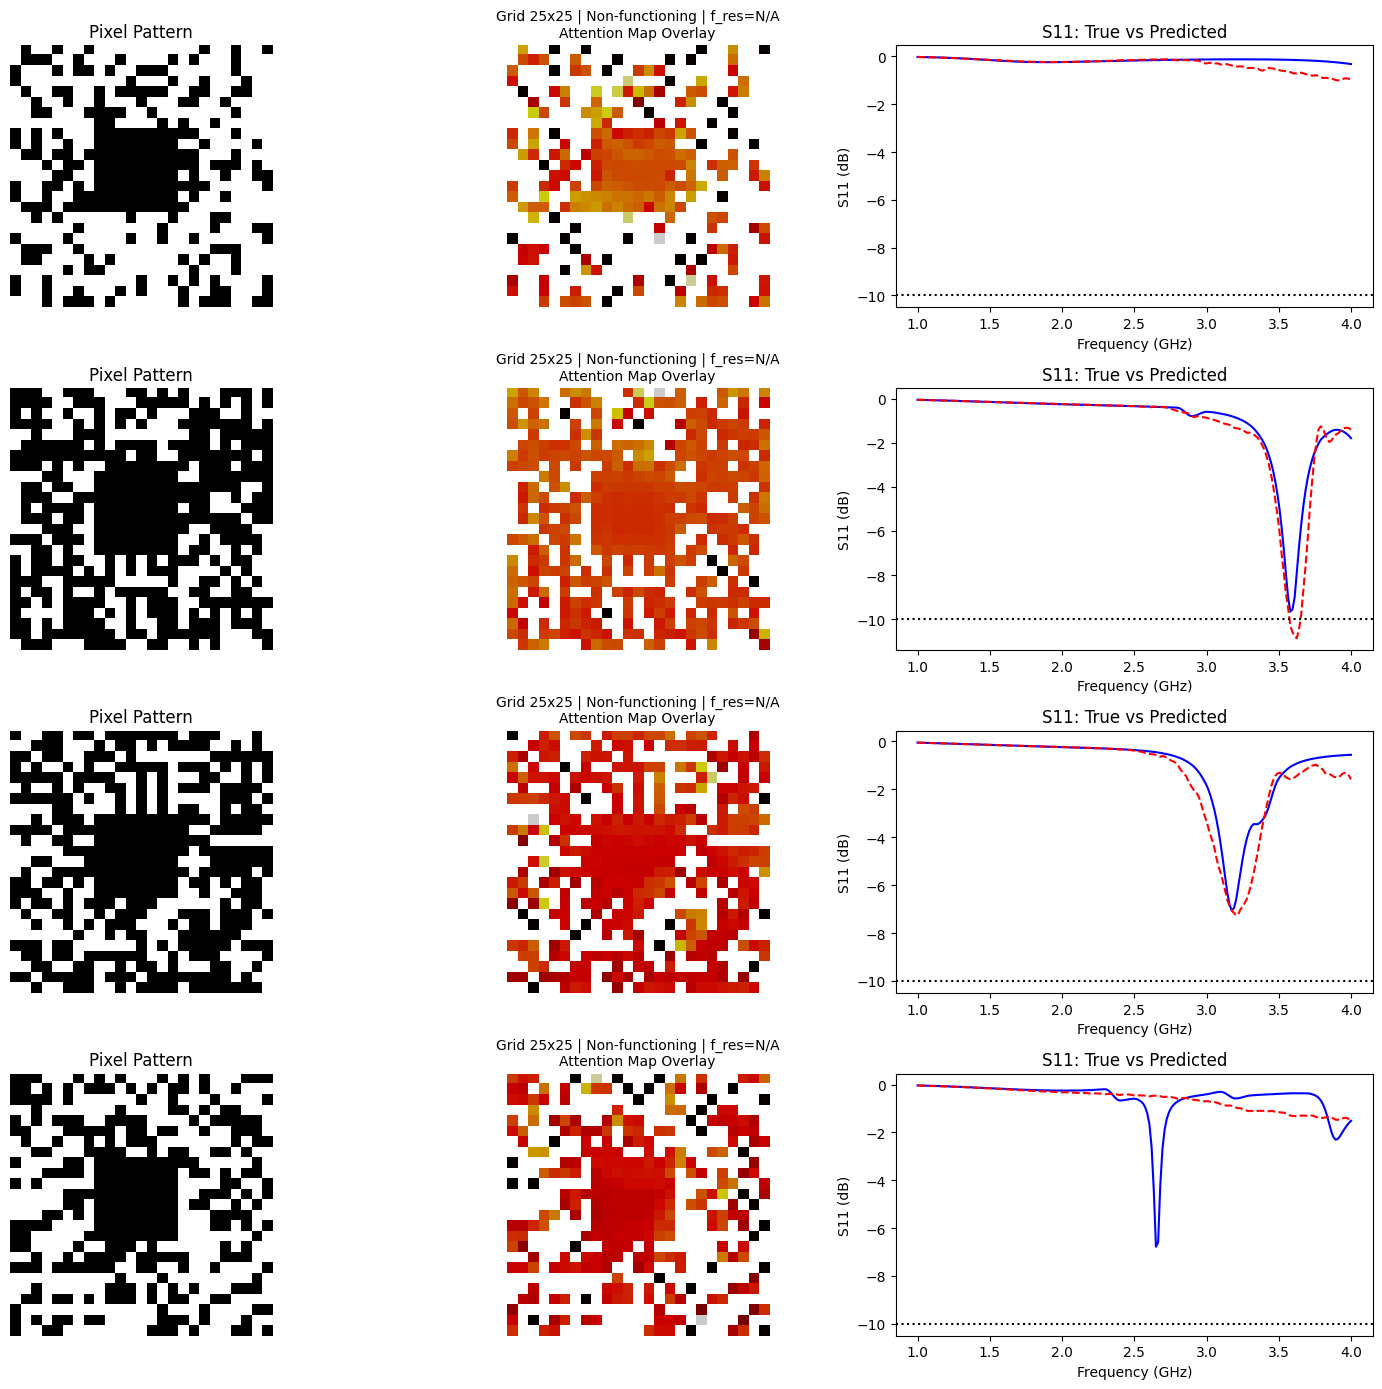

Saved non-functioning comparison to /content/drive/MyDrive/antenna_gnn/figures/attention_nonfunctioning.png


In [8]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
for i, data in enumerate(tqdm(selected_nonfunc, desc="Generating non-functioning plots")):
    plot_attention_figure(data, attn_model, 25, None, ax_row=axes[i])

plt.tight_layout()
nonfunc_path = f'{DATA_ROOT}/figures/attention_nonfunctioning.png'
plt.savefig(nonfunc_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved non-functioning comparison to {nonfunc_path}")


**Observation:** For non-functioning antennas, the attention maps tend to be scattered, fragmented, or overly concentrated on isolated islands of metal that are disconnected from the main feed. Without a continuous resonant path, the message passing fails to aggregate a strong, unified spatial feature, accurately predicting a flat/poor S11 response.